# Title :Linear Regression to predict medical insurance costs


In [105]:
 #import libraries
import pandas as pd                     # for loading and working with data tables
import matplotlib.pyplot as plt        # for plotting graphs

from sklearn.model_selection import train_test_split   # to split data into training and testing sets
from sklearn.preprocessing import StandardScaler       # to scale features
from sklearn.linear_model import LinearRegression      # linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [106]:
# functions to evaluate the model

plt.rcParams["figure.figsize"] = (7, 4)   # set default figure size
plt.rcParams["axes.grid"] = True          # show grid on plots

# Load dataset

In [107]:
# load data
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA 

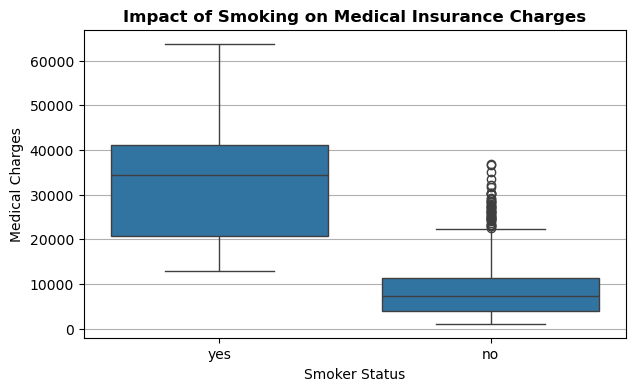

In [108]:
import seaborn as sns
sns.boxplot(x="smoker", y="charges", data=df,)
plt.title("Impact of Smoking on Medical Insurance Charges", fontsize=12, fontweight="bold")
plt.xlabel("Smoker Status", fontsize=10)
plt.ylabel("Medical Charges", fontsize=10)
plt.show()

# clean Data 

In [109]:
df.isnull().sum() # for missing value 
# we notice that we don't need to clean data _no missing value here !

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Define features and Target

In [110]:

X = df.drop("charges", axis=1) # input feature 
y = df["charges"] # output traget


In [111]:
X.shape

(1338, 6)

In [112]:
y.shape

(1338,)

# Preprocessing data 

In [113]:
from sklearn import preprocessing
# select all categorical variables
df_categorical = X.select_dtypes(include=['object'])
df_categorical.head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [114]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df_categorical = df_categorical.apply(le.fit_transform)
X = X.drop(df_categorical.columns, axis=1)

# add encoded columns
X = pd.concat([X, df_categorical], axis=1)
print(X.head())


   age     bmi  children  sex  smoker  region
0   19  27.900         0    0       1       3
1   18  33.770         1    1       0       2
2   28  33.000         3    1       0       2
3   33  22.705         0    1       0       1
4   32  28.880         0    1       0       1


# Split Data 

In [115]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [116]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)# compute mean and std from training data, then scale it
X_test_scaled = scaler.transform(X_test)
# Xscaled =X- mean /std

# Model training 

In [117]:
# Train the model
model = LinearRegression()

In [118]:
model.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
# Show coefficients
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [3535.60851317 1925.9112989   429.49110392 -140.54499098 9727.71068596
 -354.97389144]
Bias: 13276.698553898505


# Model evaluation 

In [120]:
# prdicted vs. Actual
y_pred = model.predict(X_test_scaled)
# use the trained model to make predictions

results = pd.DataFrame({
    "Actual charges": y_test.values,     # real prices
    "Predicted charges": y_pred          # predicted prices
})


In [121]:
results.head()

,Actual charges,Predicted charges
0,1646.4297,4500.484328
1,11353.2276,12819.457878
2,8798.5930,12397.712728
3,10381.4787,13430.343290
4,2103.0800,531.776110


In [122]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred)
# how well the model fits the data (closer to 1 is better)

# print results
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

MAE  = 4139.313
RMSE = 6065.824
R^2  = 0.74


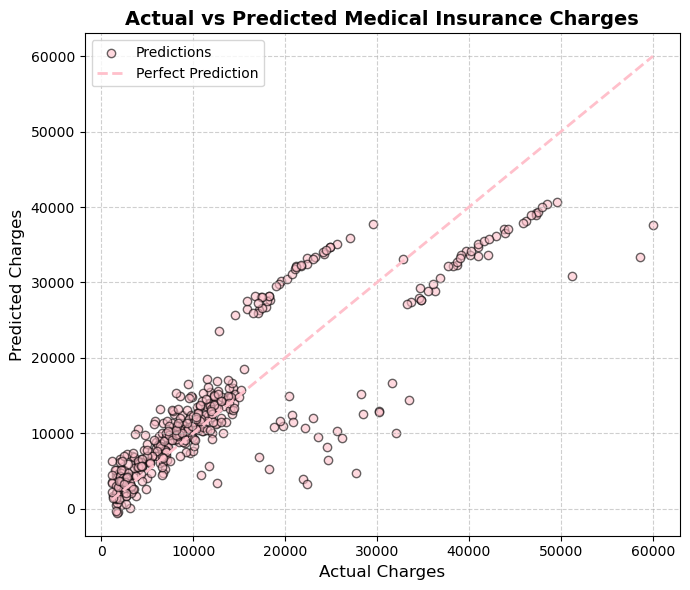

In [123]:
# Visualize model with real data

plt.figure(figsize=(7,6))

# scatter plot
plt.scatter(y_test, y_pred, alpha=0.6, color="pink", edgecolor="k", label="Predictions")

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="pink",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Medical Insurance Charges", fontsize=14, fontweight="bold")
plt.xlabel("Actual Charges", fontsize=12)
plt.ylabel("Predicted Charges", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()